In [5]:
# Configuração do caminho e Imports do seu pacote modularizado
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
%pip install numpy matplotlib tensorflow
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from mlp import NeuralNetwork, DenseLayer, ReLU, Sigmoid, check_gradients, train_network

# Preparação dos Dados

(X_train_raw, Y_train_raw), (X_test_raw, Y_test_raw) = mnist.load_data()

# Pré-processamento
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1).T / 255.0
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1).T / 255.0

# One-hot encoding 
num_classes = 10
Y_train_oh = np.zeros((num_classes, Y_train_raw.size))
Y_train_oh[Y_train_raw, np.arange(Y_train_raw.size)] = 1

# Execução e Comparação de Configurações
np.random.seed(42) # Para comparação justa

net_check = NeuralNetwork()
net_check.add(DenseLayer(784, 10))
# Usei apenas 10 exemplos para o check ser instantâneo
check_gradients(net_check, X_train[:, :10], Y_train_oh[:, :10])

print("\n Configuração 1: 3 Camadas (2 Ocultas), Ativação ReLU, LR = 0.1")
net1 = NeuralNetwork()
net1.add(DenseLayer(input_dim=784, output_dim=128))
net1.add(ReLU())
net1.add(DenseLayer(input_dim=128, output_dim=64))
net1.add(ReLU())
net1.add(DenseLayer(input_dim=64, output_dim=10))

history1 = train_network(net1, X_train, Y_train_oh, Y_train_raw, X_test, Y_test_raw, epochs=15, batch_size=64, lr=0.1)

print("\n Configuração 2: 2 Camadas (1 Oculta), Ativação Sigmoid, LR = 0.3")
net2 = NeuralNetwork()
net2.add(DenseLayer(input_dim=784, output_dim=128))
net2.add(Sigmoid())
net2.add(DenseLayer(input_dim=128, output_dim=10))

history2 = train_network(net2, X_train, Y_train_oh, Y_train_raw, X_test, Y_test_raw, epochs=15, batch_size=64, lr=0.3)

  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB

I0000 00:00:1781124019.560155   32629 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781124019.561243   32629 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781124019.651471   32629 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781124021.756989   32629 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 Gradient Check:
Pixel 400 | Input Médio: 0.2533
Analítico: -0.0749291682
Numérico:  -0.0749291673
Diferença: 9.24e-10 -> CORRETO

 Configuração 1: 3 Camadas (2 Ocultas), Ativação ReLU, LR = 0.1
Época 01 | Perda: 0.1699 | Acc Treino: 94.95% | Acc Teste: 94.80%
Época 02 | Perda: 0.1154 | Acc Treino: 96.65% | Acc Teste: 95.94%
Época 03 | Perda: 0.0763 | Acc Treino: 97.75% | Acc Teste: 96.85%
Época 04 | Perda: 0.0734 | Acc Treino: 97.80% | Acc Teste: 96.80%
Época 05 | Perda: 0.0559 | Acc Treino: 98.38% | Acc Teste: 96.97%
Época 06 | Perda: 0.0409 | Acc Treino: 98.84% | Acc Teste: 97.54%
Época 07 | Perda: 0.0419 | Acc Treino: 98.78% | Acc Teste: 97.35%
Época 08 | Perda: 0.0277 | Acc Treino: 99.28% | Acc Teste: 97.81%
Época 09 | Perda: 0.0249 | Acc Treino: 99.33% | Acc Teste: 97.68%
Época 10 | Perda: 0.0228 | Acc Treino: 99.41% | Acc Teste: 97.61%
Época 11 | Perda: 0.0167 | Acc Treino: 99.61% | Acc Teste: 97.70%
Época 12 | Perda: 0.0151 | 

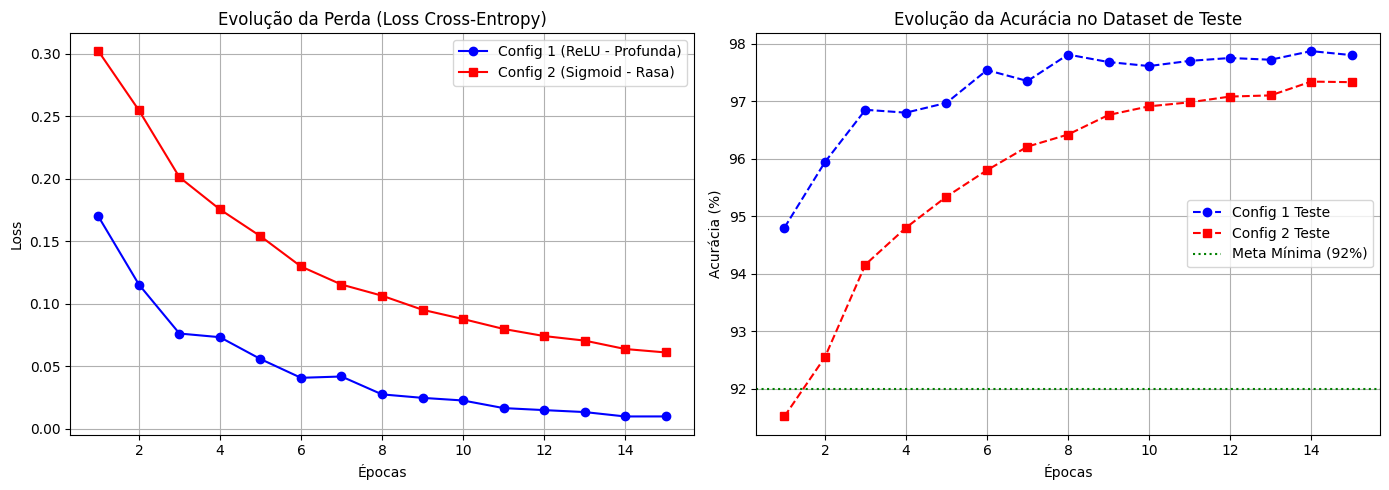

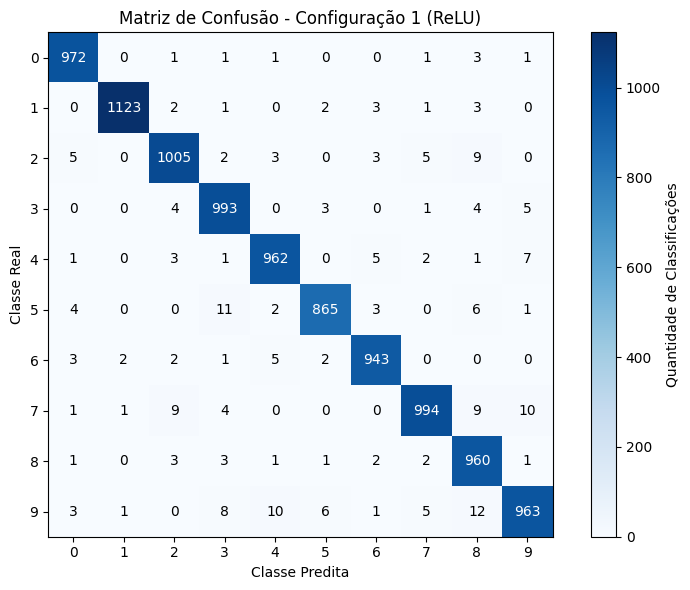

In [6]:
# Geração dos Gráficos e da Matriz de Confusão Comentada
epochs_range = range(1, 16)

plt.figure(figsize=(14, 5))

# Gráfico 1: Curva de Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history1['loss'], label='Config 1 (ReLU - Profunda)', color='blue', marker='o')
plt.plot(epochs_range, history2['loss'], label='Config 2 (Sigmoid - Rasa)', color='red', marker='s')
plt.title('Evolução da Perda (Loss Cross-Entropy)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico 2: Curva de Acurácia
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history1['test_acc'], label='Config 1 Teste', color='blue', linestyle='--', marker='o')
plt.plot(epochs_range, history2['test_acc'], label='Config 2 Teste', color='red', linestyle='--', marker='s')
plt.axhline(y=92.0, color='green', linestyle=':', label='Meta Mínima (92%)')
plt.title('Evolução da Acurácia no Dataset de Teste')
plt.xlabel('Épocas')
plt.ylabel('Acurácia (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
# Salvar em resultados
plt.savefig('../results/curvas_aprendizado.png')
plt.show()

# Calculo e Plot da Matriz de Confusão

# Obter predições da Configuração 1 (Rede com melhor acurácia esperada) para os dados de teste
test_out_final = net1.forward(X_test)
test_preds_final = np.argmax(test_out_final, axis=0)

# Inicializar a matriz vazia (10x10 para os dígitos de 0 a 9)
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

# Preencher a matriz acumulando as combinações de classes reais (linhas) e preditas (colunas)
for real, pred in zip(Y_test_raw, test_preds_final):
    confusion_matrix[real, pred] += 1

# Configurar a figura para exibição gráfica da Matriz de Confusão
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
plt.title('Matriz de Confusão - Configuração 1 (ReLU)')
plt.colorbar(label='Quantidade de Classificações')

# Definir marcadores dos eixos de 0 a 9
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')

# Inserir os valores numéricos dentro de cada quadrante da matriz para facilitar a leitura
limiar_cor = confusion_matrix.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, format(confusion_matrix[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if confusion_matrix[i, j] > limiar_cor else "black")

plt.tight_layout()
# Opcional: Salvar em resultados
plt.savefig('../results/matriz_confusao.png')
plt.show()